In [3]:
import torch
from torch.nn.functional import threshold

from models import double_well_model, simulate, plot_traj_set

# import module optimization to use DeGAS
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


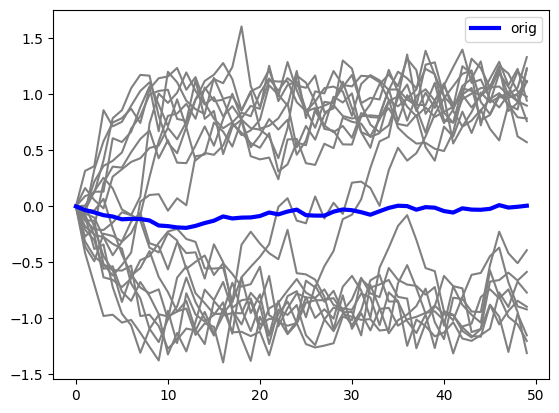

In [2]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time_steps = 50
#fast convergence to x=2, with little noise
params = {'time': time_steps,      # time steps
            'init_x':-1.0,  # initial x
            'a': 1.0,        #
            'b': 1.0,       #
            'h': 0.15,
            'sigma': 0.65}

#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.0,  # initial x
            'a': 1.0,        #noise
            'b': 1.0,        #
            'h': 0.44,    #this the sqrt of the h I would like to use
            'sigma': 0.4}



trajs = simulate(double_well_model, 100, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

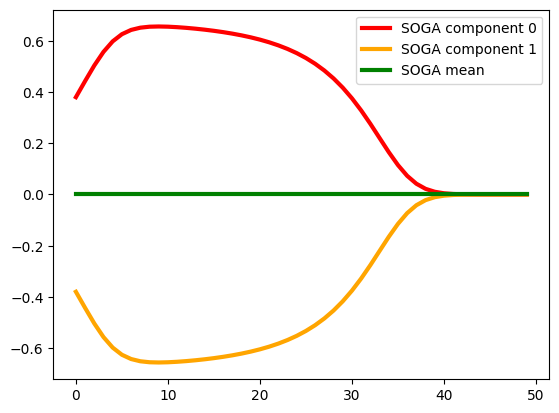

In [111]:
compiledFile = compile2SOGA('double_well.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# initial parameters
init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.4, 'xinit1':0.38, 'xinit2':-0.38}
params_dict = initialize_params(init_params)  

# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

T = 50
#output_dist
#plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Plot the two components of the distribution
output_dist.gm.mu[0]
plt.plot(range(T), output_dist.gm.mu[0][:T].detach(), lw=3, color='red', label='SOGA component 0')
plt.plot(range(T), output_dist.gm.mu[1][:T].detach(), lw=3, color='orange', label='SOGA component 1')
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Convert covariance to a 1D variance vector aligned with the mean
cov_raw = output_dist.gm.cov().detach().numpy()
if cov_raw.ndim == 2:
    cov = np.diag(cov_raw)[:T]
else:
    cov = np.squeeze(cov_raw)[:T]

mean = output_dist.gm.mean()[:T].detach().numpy()
#plt.fill_between(range(T), mean - 2 * np.sqrt(cov), mean + 2 * np.sqrt(cov), color='green', alpha=0.2, label='SOGA variance')
plt.legend()

In [103]:
output_dist.gm.marg_comp_pdf(torch.tensor([0.0]), 0, 2)

tensor([0.2313], grad_fn=<ExpBackward0>)

In [110]:
loss = lambda output_dist: -output_dist.gm.marg_comp_pdf(torch.tensor([1.0]), 0, 49) - 0.000001*output_dist.gm.marg_comp_pdf(torch.tensor([0.0]), 0, 2) 
loss(output_dist)

cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.4, 'xinit1':0.3, 'xinit2':-0.3}
params_dict = initialize_params(init_params) 

#set some parameters to be non-optimizable (e.g., the initial conditions)
params_dict['a'].requires_grad = False
params_dict['b'].requires_grad = False
params_dict['h'].requires_grad = False
params_dict['sigma'].requires_grad = False



# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.005)

# print results:
for key, value in params_dict.items():
    print(f"{key}: {value.item()}")


a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.30499984451009854 xinit2: -0.3  loss: -0.23242275720670172
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.3100045784677597 xinit2: -0.3  loss: -0.23242449954360486
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.3150165093818063 xinit2: -0.3  loss: -0.23242655627668543
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.32003692429712 xinit2: -0.3  loss: -0.23242901001530478
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.3250657799856115 xinit2: -0.3  loss: -0.23243197224942633
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.3301013412893356 xinit2: -0.3  loss: -0.23243559610104192
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.33513977124375344 xinit2: -0.3  loss: -0.23244009601949175
a: 1.0 b: 1.0 h: 0.44 sigma: 0.4 xinit1: 0.34017468415536295 xinit2: -0.3  loss: -0.2324457790254785


KeyboardInterrupt: 